In [29]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

## Load file

In [30]:
X_Uncleaned = pd.read_csv("./X.csv")
y_Uncleaned = pd.read_csv("./y.csv")

X = X_Uncleaned.iloc[:, 1:]  # remove index
y = y_Uncleaned.iloc[:, 1:]  # remove index

# display(y.head())

In [31]:
loadPickleFile = pd.read_pickle("./xgb_model_withgpa.pkl")
# print(loadPickleFile)

### Preprocess X and Y

In [32]:
# Stratify on binary depression status just to keep it balanced
y_binary = np.where(y >= 10, 1, 0)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y_binary, random_state=42
)

# Binary ground truth for evaluation
y_test_binary = np.where(y_test >= 10, 1, 0)

### Build Model

In [33]:
# Extract the hyperparams
params = (
    loadPickleFile.get_params()
)  # --> Used to get paramters of a fresh model (not trained yet)

## Step 2A: Baseline Training (No Balancing)

In [34]:
model_baseline = XGBRegressor(**params)
model_baseline.fit(X_train, y_train)

y_pred_scores_baseline = model_baseline.predict(X_test)
y_pred_binary_baseline = np.where(y_pred_scores_baseline >= 10, 1, 0)

The model achieved an overall accuracy of 95%, with precision and F1-scores appearing strong at first glance. However, closer inspection reveals a critical issue related to class imbalance.

## Step 2B: Undersampling the Majority Class

In [35]:
# Step 1: Create binary labels
y_train_binary = np.where(y_train >= 10, 1, 0)

# Step 2: Undersample using binary labels
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_binary_under = rus.fit_resample(X_train, y_train_binary)

# Step 3: Extract continuous y values corresponding to the resampled rows
# rus.fit_resample returns arrays in the same order, so we can just re-index y_train
# But we need to find WHICH rows were selected → use indexing mask
mask = rus.sample_indices_ if hasattr(rus, "sample_indices_") else None

if mask is not None:
    y_train_cont_under = np.array(y_train)[mask]
else:
    # fallback if sample_indices_ isn't available (newer imblearn versions)
    # match y_train_cont to X_train_under manually
    raise RuntimeError("sample_indices_ not found, need alternative matching logic.")

# Step 4: Train the regressor
model_under = XGBRegressor(**params)
model_under.fit(X_train_under, y_train_cont_under)

# Step 5: Predict and evaluate
y_pred_scores_under = model_under.predict(X_test)
y_pred_binary_under = np.where(y_pred_scores_under >= 10, 1, 0)

## Step 2C: Oversampling with SMOTE

In [36]:
# Step 1: Create binary labels for oversampling
y_train_binary = np.where(y_train >= 10, 1, 0)

# Step 2: Run SMOTE
sm = SMOTE(random_state=42)
X_train_over, y_train_binary_over = sm.fit_resample(X_train, y_train_binary)

# Step 3: Assign continuous PHQ-9 scores for regression training
# Option 1: Use mean PHQ-9 values per class as a rough estimate
mean_0 = y_train[y_train_binary == 0].mean()
mean_1 = y_train[y_train_binary == 1].mean()

# Generate continuous training targets for regression
y_train_cont_over = np.where(y_train_binary_over == 0, mean_0, mean_1)

# Step 4: Train the model
model_over = XGBRegressor(**params)
model_over.fit(X_train_over, y_train_cont_over)

# Step 5: Predict and evaluate
y_pred_scores_over = model_over.predict(X_test)

# Convert to binary classification for evaluation
y_pred_binary_over = np.where(y_pred_scores_over >= 10, 1, 0)

### Print all results

In [37]:
print("Baseline (No Balancing):")

print(
    classification_report(
        y_test_binary, y_pred_binary_baseline, target_names=["None/Mild", "Moderate+"]
    )
)

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_binary, y_pred_binary_baseline))

Baseline (No Balancing):
              precision    recall  f1-score   support

   None/Mild       0.94      1.00      0.97      1439
   Moderate+       1.00      0.74      0.85       362

    accuracy                           0.95      1801
   macro avg       0.97      0.87      0.91      1801
weighted avg       0.95      0.95      0.95      1801

Confusion Matrix:

[[1439    0]
 [  93  269]]


In [38]:
print("Undersampled:")
print(
    classification_report(
        y_test_binary, y_pred_binary_under, target_names=["None/Mild", "Moderate+"]
    )
)

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_binary, y_pred_binary_under))

Undersampled:
              precision    recall  f1-score   support

   None/Mild       1.00      0.94      0.97      1439
   Moderate+       0.81      1.00      0.89       362

    accuracy                           0.95      1801
   macro avg       0.90      0.97      0.93      1801
weighted avg       0.96      0.95      0.95      1801

Confusion Matrix:

[[1352   87]
 [   0  362]]


In [39]:
print("Oversampled:")
print(
    classification_report(
        y_test_binary, y_pred_binary_over, target_names=["None/Mild", "Moderate+"]
    )
)

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_binary, y_pred_binary_over))

Oversampled:
              precision    recall  f1-score   support

   None/Mild       1.00      0.94      0.97      1439
   Moderate+       0.80      1.00      0.89       362

    accuracy                           0.95      1801
   macro avg       0.90      0.97      0.93      1801
weighted avg       0.96      0.95      0.95      1801

Confusion Matrix:

[[1351   88]
 [   1  361]]


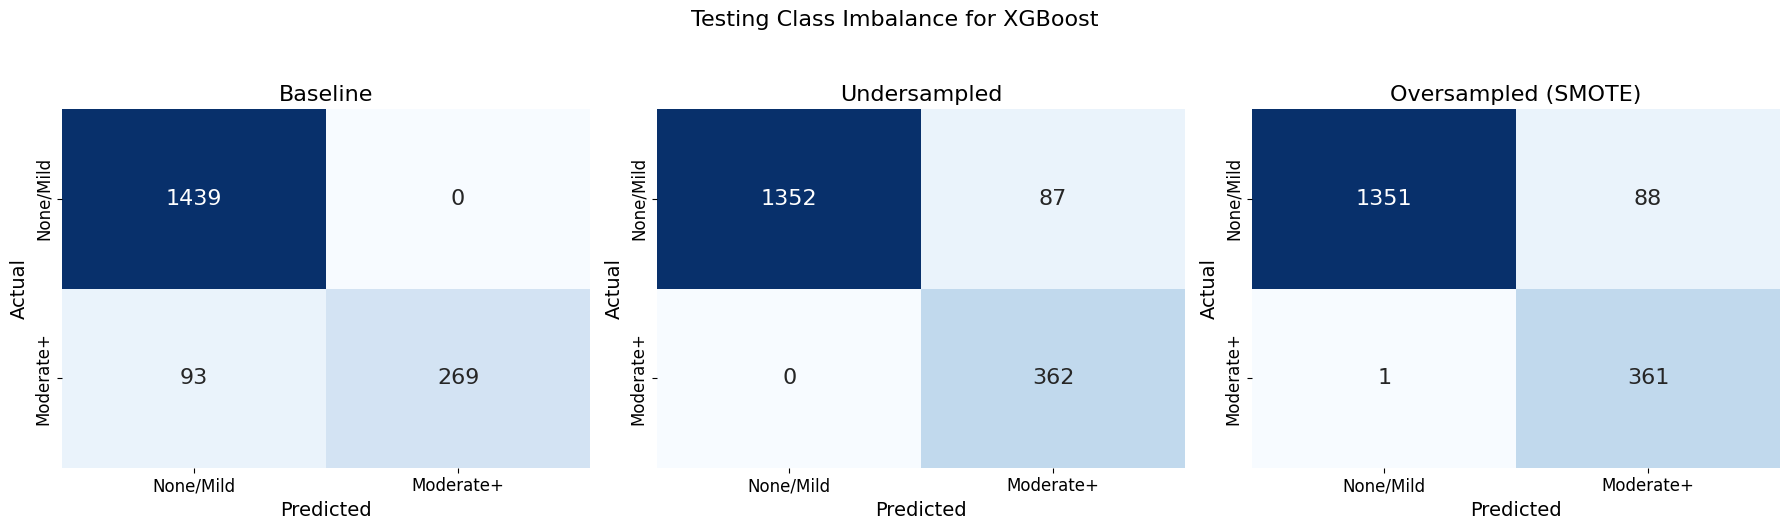

In [44]:
# Mock values — replace these with actual predictions after running models
# Example placeholders:
y_true = y_test_binary

# Confusion matrices
cm_baseline = confusion_matrix(y_true, y_pred_binary_baseline)
cm_under = confusion_matrix(y_true, y_pred_binary_under)
cm_over = confusion_matrix(y_true, y_pred_binary_over)

# Labels
labels = ["None/Mild", "Moderate+"]

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = ["Baseline", "Undersampled", "Oversampled (SMOTE)"]
cms = [cm_baseline, cm_under, cm_over]

for ax, cm, title in zip(axes, cms, titles):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
        annot_kws={"size": 16},
        cbar=False,
    )
    ax.set_xlabel("Predicted", fontsize=14)
    ax.set_ylabel("Actual", fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.tick_params(axis="both", which="major", labelsize=12)

plt.suptitle("Testing Class Imbalance for XGBoost", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()